<a href="https://colab.research.google.com/github/Group06-The-imputers/Hackathon-group06/blob/main/Hackathon_group06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
%matplotlib inline
import os, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn import __version__ as sklver
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay,
    classification_report)

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
datapath = "/content/drive/MyDrive/dataset_B_training.csv"


df = pd.read_csv(datapath)
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,construction,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,real_estate,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


In [14]:
# Make pandas printouts compact
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Targets we expect for Dataset B (train whichever are present)
CANDIDATE_TARGETS = ["h1n1_vaccine"]
# ---------------------------------------------------------
# 1) Load Data
# ---------------------------------------------------------
train_df = pd.read_csv(datapath)
print("Training shape:", train_df.shape)
print("Columns:", list(train_df.columns))

# Auto-detect available targets in Dataset B training
available_targets = [t for t in CANDIDATE_TARGETS if t in train_df.columns]
if not available_targets:
    print("\n⚠️ No target columns found among", CANDIDATE_TARGETS,
          "\n   Please verify your training file includes at least one of them.")
else:
    print("\nDetected target(s):", available_targets)

# ID column (assumed present)
ID_COL = "respondent_id" if "respondent_id" in train_df.columns else None

# ---------------------------------------------------------
# 2) BASIC EDA
# ---------------------------------------------------------
print("\n--- HEAD ---")
display(train_df.head())

print("\n--- INFO ---")
print(train_df.info())

print("\n--- Missing values (top 40) ---")
missing_counts = train_df.isna().sum().sort_values(ascending=False)
display(missing_counts.head(40))

# If any target exists, show distribution(s)
for tgt in available_targets:
    print(f"\n--- Target distribution: {tgt} ---")
    display(train_df[tgt].value_counts(dropna=False))
    if set(train_df[tgt].dropna().unique()).issubset({0,1}):
        print(train_df[tgt].value_counts(normalize=True).rename("proportion"))

# Quick look at dtypes
print("\n--- dtypes ---")
display(train_df.dtypes)

# Identify features (exclude id + targets)
feature_cols = [c for c in train_df.columns if c not in ([ID_COL] if ID_COL else []) + available_targets]
print("\n# Features:", len(feature_cols))

# Split features by dtype for preprocessing
cat_cols = [c for c in feature_cols if train_df[c].dtype == "object"]
num_cols = [c for c in feature_cols if train_df[c].dtype != "object"]

print(f"\nCategorical features ({len(cat_cols)}):", cat_cols[:20], ("..." if len(cat_cols) > 20 else ""))
print(f"Numeric features ({len(num_cols)}):", num_cols[:20], ("..." if len(num_cols) > 20 else ""))

# Optional: quick numeric summary
print("\n--- Numeric summary ---")
display(train_df[num_cols].describe().T if num_cols else pd.DataFrame({"note": ["no numeric columns detected"]}))

Training shape: (4756, 31)
Columns: ['respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'household_adults', 'household_children', 'employment_sector', 'h1n1_vaccine']

Detected target(s): ['h1n1_vaccine']

--- HEAD ---


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,1.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,construction,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,2.0,18 - 34 Years,Some College,White,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,4.0,2.0,45 - 54 Years,College Graduate,White,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,real_estate,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,4.0,18 - 34 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,2.0,2.0,1.0,18 - 34 Years,< 12 Years,White,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  heal

,0
employment_sector,2364
health_insurance,1925
income_poverty,712
doctor_recc_h1n1,319
rent_or_own,315
employment_status,235
marital_status,226
education,224
chronic_med_condition,161
child_under_6_months,134



--- Target distribution: h1n1_vaccine ---


,count
h1n1_vaccine,
0,2882
1,1874


h1n1_vaccine
0    0.605971
1    0.394029
Name: proportion, dtype: float64

--- dtypes ---


,0
respondent_id,int64
h1n1_concern,float64
h1n1_knowledge,float64
behavioral_antiviral_meds,float64
behavioral_avoidance,float64
behavioral_face_mask,float64
behavioral_wash_hands,float64
behavioral_large_gatherings,float64
behavioral_outside_home,float64
behavioral_touch_face,float64



# Features: 29

Categorical features (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector'] 
Numeric features (19): ['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'household_adults', 'household_children'] 

--- Numeric summary ---


,count,mean,std,min,25%,50%,75%,max
h1n1_concern,4741.0,1.658933,0.892478,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,4734.0,1.307140,0.612811,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4739.0,0.057396,0.232622,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4729.0,0.740960,0.438154,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4752.0,0.077652,0.267651,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,0.842039,0.364743,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,0.359385,0.479871,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4741.0,0.341278,0.474189,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4736.0,0.704814,0.456174,0.0,0.0,1.0,1.0,1.0
doctor_recc_h1n1,4437.0,0.290286,0.453946,0.0,0.0,0.0,1.0,1.0


In [15]:
# ---------------------------------------------------------
# 3) PREPROCESSING (minimal, baseline-friendly)
#    - Numeric: median impute
#    - Categorical: most_frequent impute + one-hot encode
#      (OneHotEncoder flags differ across scikit-learn versions → handled below)
# ---------------------------------------------------------
major, minor = map(int, sklver.split(".")[:2])
use_legacy_flag = (major, minor) < (1, 2)   # True for scikit-learn < 1.2

ohe_kwargs = {"handle_unknown": "ignore"}
if use_legacy_flag:
    ohe_kwargs["sparse"] = False            # old API
else:
    ohe_kwargs["sparse_output"] = False     # new API

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(**ohe_kwargs))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    remainder="drop"
)

def get_ohe_feature_names(preprocessor, cat_cols):
    """
    Version-safe retrieval of OHE output feature names.
    """
    if not cat_cols:
        return []
    ohe = preprocessor.named_transformers_["cat"]["ohe"]
    # Try new API first
    if hasattr(ohe, "get_feature_names_out"):
        return list(ohe.get_feature_names_out(cat_cols))
    # Fallback for very old versions
    if hasattr(ohe, "get_feature_names"):
        return list(ohe.get_feature_names(cat_cols))
    # Last resort: generic names
    return [f"{col}_encoded_{i}" for col in cat_cols for i in range(1000)]  # overshoot guard (won't be used fully)



BASELINE: RandomForestClassifier for target: h1n1_vaccine

Metrics [h1n1_vaccine]
Accuracy  : 0.7458
Precision : 0.7059
Recall    : 0.6080
F1-score  : 0.6533
ROC-AUC   : 0.7957

Classification report:
              precision    recall  f1-score   support

           0     0.7663    0.8354    0.7993       577
           1     0.7059    0.6080    0.6533       375

    accuracy                         0.7458       952
   macro avg     0.7361    0.7217    0.7263       952
weighted avg     0.7425    0.7458    0.7418       952



<Figure size 640x480 with 0 Axes>

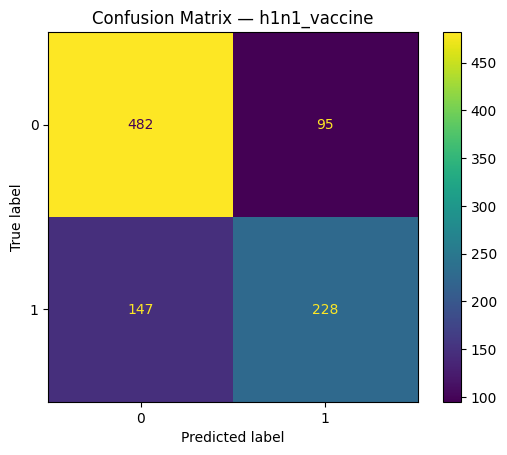

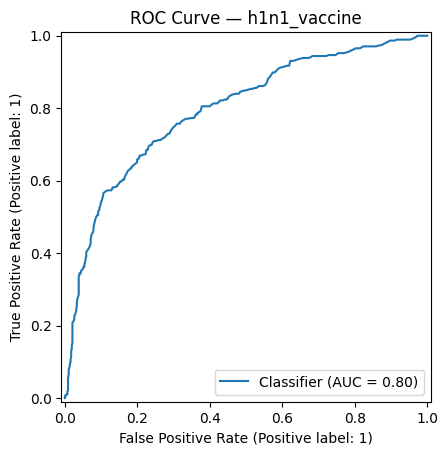


Top 30 features by importance — h1n1_vaccine


,feature,importance
9,doctor_recc_h1n1,0.106958
15,opinion_h1n1_risk,0.093356
14,opinion_h1n1_vacc_effective,0.086670
16,opinion_h1n1_sick_from_vacc,0.040282
0,h1n1_concern,0.038259
1,h1n1_knowledge,0.029133
17,household_adults,0.028228
18,household_children,0.025815
12,health_worker,0.023300
10,chronic_med_condition,0.018698


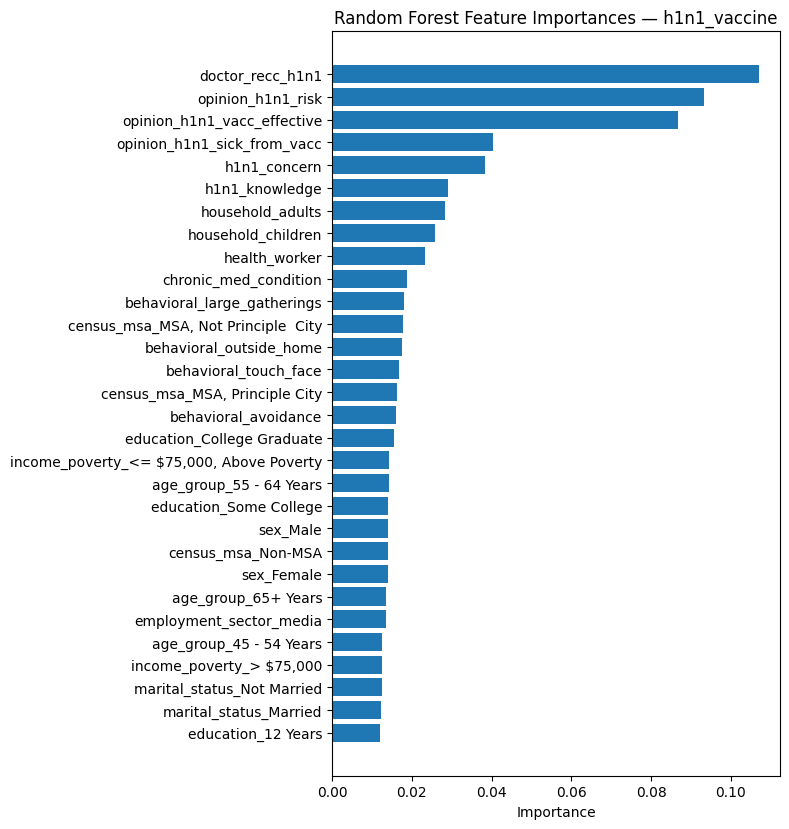

In [16]:
# ---------------------------------------------------------
# 4) BASELINE MODEL: RandomForestClassifier
#    We'll train a separate RF for each available target.
# ---------------------------------------------------------
results = []

for target in available_targets:
    print("\n" + "="*78)
    print(f"BASELINE: RandomForestClassifier for target: {target}")
    print("="*78)

    # Drop rows with target NaN (if any)
    data = train_df.dropna(subset=[target]).copy()
    if data.empty:
        print(f"⚠️ Skipping {target}: no non-NaN labels found.")
        continue

    X = data[feature_cols]
    y = data[target].astype(int)  # ensure binary int

    # Stratified split to preserve class balance
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Baseline RF (simple; tune later if needed)
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42
    )

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", rf)
    ])

    # Fit
    pipe.fit(X_train, y_train)
    # Predict
    y_pred  = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]

    # Metrics
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    # ROC-AUC (guard if only one class)
    try:
        auc  = roc_auc_score(y_val, y_proba)
    except ValueError:
        auc = np.nan

    print(f"\nMetrics [{target}]")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    print("\nClassification report:")
    print(classification_report(y_val, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    plt.figure()
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {target}")
    plt.show()

    # ROC Curve
    try:
        RocCurveDisplay.from_predictions(y_val, y_proba)
        plt.title(f"ROC Curve — {target}")
        plt.show()
    except ValueError:
        pass

    # -----------------------------------------------------
    # 4a) Feature Importances (approximate)
    #     Get feature names after preprocessing, then RF importances
    # -----------------------------------------------------
    # Fit a preprocessing-only transformer to learn OHE categories
    preprocessor.fit(X_train)

    out_num_names = num_cols
    out_cat_names = get_ohe_feature_names(preprocessor, cat_cols)
    out_feature_names = out_num_names + out_cat_names

    # Retrieve fitted RF from pipeline
    fitted_rf = pipe.named_steps["clf"]
    importances = fitted_rf.feature_importances_

    # Align lengths (just in case)
    k = min(len(importances), len(out_feature_names))
    fi_df = pd.DataFrame({
        "feature": out_feature_names[:k],
        "importance": importances[:k]
    }).sort_values("importance", ascending=False).head(30)

    print(f"\nTop 30 features by importance — {target}")
    display(fi_df)

    # Plot top importances
    plt.figure(figsize=(8, max(4, len(fi_df) * 0.28)))
    plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
    plt.title(f"Random Forest Feature Importances — {target}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    # Save results summary
    results.append({
        "target": target,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    })

In [17]:
# ---------------------------------------------------------
# 5) Results Table (across targets)
# ---------------------------------------------------------
if results:
    res_df = pd.DataFrame(results)
    print("\n=== Baseline Results Summary ===")
    display(res_df.sort_values("roc_auc", ascending=False))
else:
    print("\nNo results to summarize (no targets found or models trained).")


=== Baseline Results Summary ===


,target,accuracy,precision,recall,f1,roc_auc
0,h1n1_vaccine,0.745798,0.705882,0.608,0.653295,0.795676


✅ XGBoost detected — will train it too.

MODEL ZOO for target: h1n1_vaccine

----------------------------------------------------------------------
Training: RandomForest_tuned

[RandomForest_tuned] Metrics — h1n1_vaccine
Accuracy  : 0.7416
Precision : 0.6787
Recall    : 0.6533
F1-score  : 0.6658
ROC-AUC   : 0.8018

Classification report:
              precision    recall  f1-score   support

           0     0.7800    0.7990    0.7894       577
           1     0.6787    0.6533    0.6658       375

    accuracy                         0.7416       952
   macro avg     0.7294    0.7261    0.7276       952
weighted avg     0.7401    0.7416    0.7407       952



<Figure size 640x480 with 0 Axes>

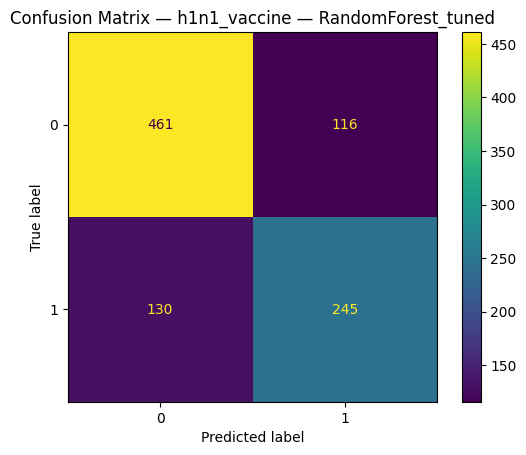

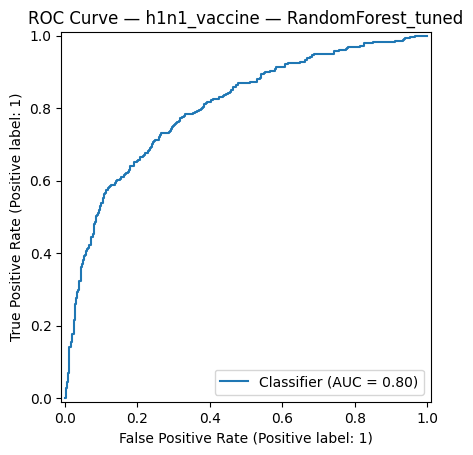


Top 30 features by importance — RandomForest_tuned (h1n1_vaccine)


,feature,importance
9,doctor_recc_h1n1,0.142162
15,opinion_h1n1_risk,0.115244
14,opinion_h1n1_vacc_effective,0.106750
16,opinion_h1n1_sick_from_vacc,0.036757
0,h1n1_concern,0.036074
1,h1n1_knowledge,0.028520
12,health_worker,0.026465
17,household_adults,0.024501
18,household_children,0.023450
10,chronic_med_condition,0.017278


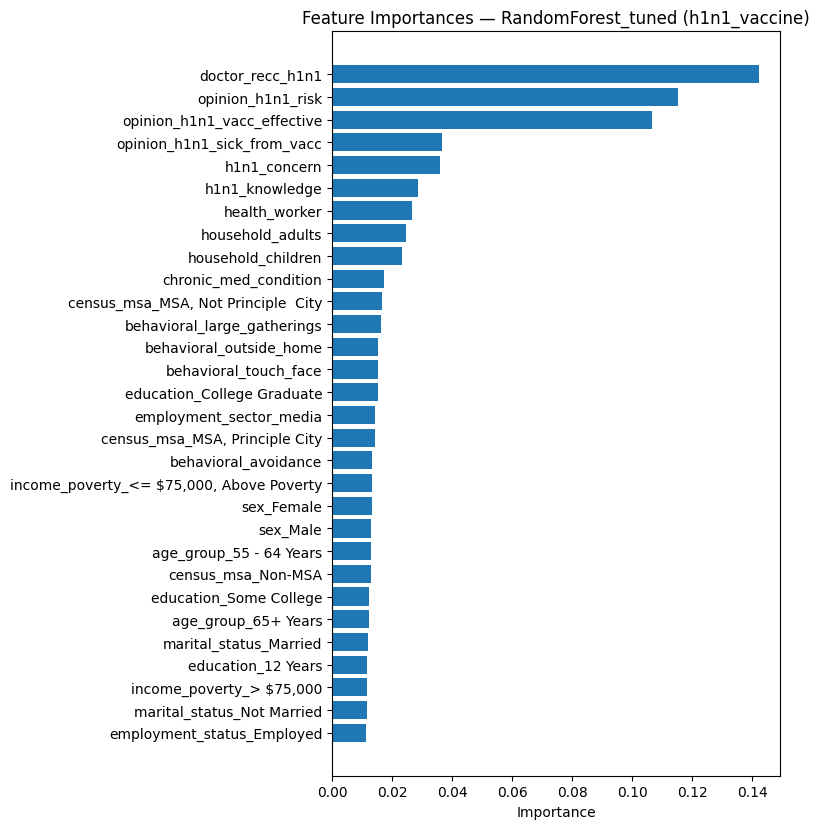


----------------------------------------------------------------------
Training: LogisticRegression

[LogisticRegression] Metrics — h1n1_vaccine
Accuracy  : 0.7416
Precision : 0.6577
Recall    : 0.7173
F1-score  : 0.6862
ROC-AUC   : 0.8157

Classification report:
              precision    recall  f1-score   support

           0     0.8048    0.7574    0.7804       577
           1     0.6577    0.7173    0.6862       375

    accuracy                         0.7416       952
   macro avg     0.7312    0.7373    0.7333       952
weighted avg     0.7468    0.7416    0.7433       952



<Figure size 640x480 with 0 Axes>

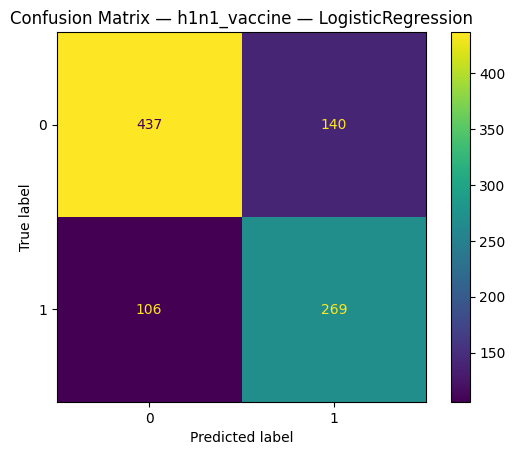

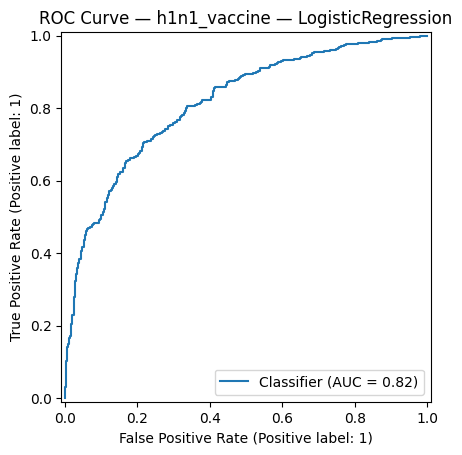


Top 30 features by |coefficient| — LogisticRegression (h1n1_vaccine)


,feature,weight,abs_weight
63,employment_sector_technology,1.749950,1.749950
9,doctor_recc_h1n1,1.673063,1.673063
47,employment_sector_administrative,0.835055,0.835055
12,health_worker,0.699213,0.699213
65,employment_sector_utilities,-0.651953,0.651953
14,opinion_h1n1_vacc_effective,0.636331,0.636331
58,employment_sector_mining,-0.624616,0.624616
56,employment_sector_manufacturing,-0.483429,0.483429
15,opinion_h1n1_risk,0.434736,0.434736
48,employment_sector_agriculture,-0.411659,0.411659


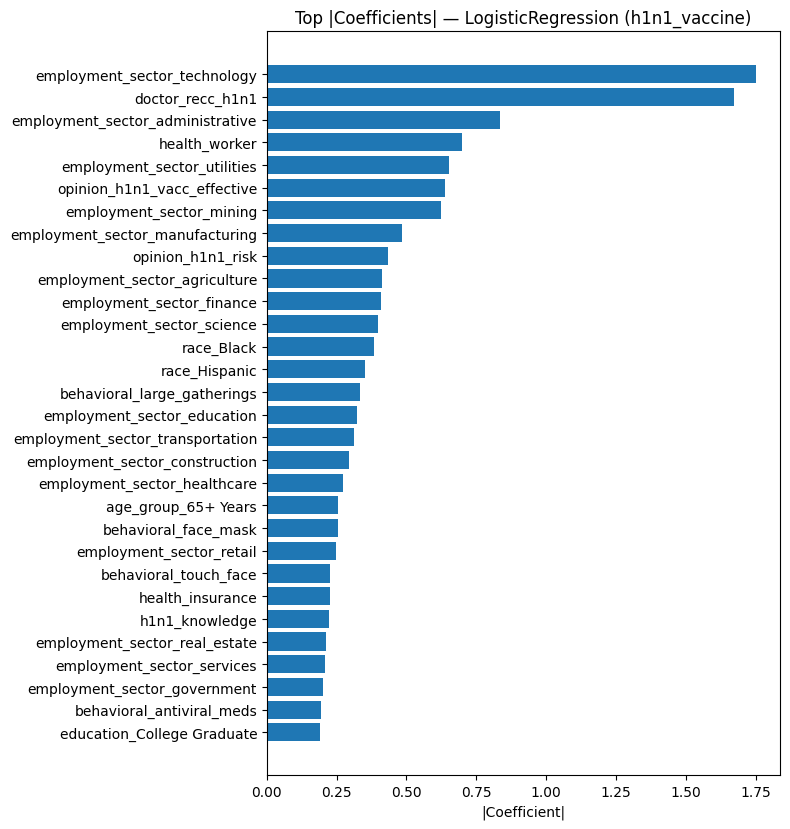


----------------------------------------------------------------------
Training: GradientBoosting

[GradientBoosting] Metrics — h1n1_vaccine
Accuracy  : 0.7616
Precision : 0.7202
Recall    : 0.6453
F1-score  : 0.6807
ROC-AUC   : 0.8107

Classification report:
              precision    recall  f1-score   support

           0     0.7841    0.8371    0.8097       577
           1     0.7202    0.6453    0.6807       375

    accuracy                         0.7616       952
   macro avg     0.7522    0.7412    0.7452       952
weighted avg     0.7589    0.7616    0.7589       952



<Figure size 640x480 with 0 Axes>

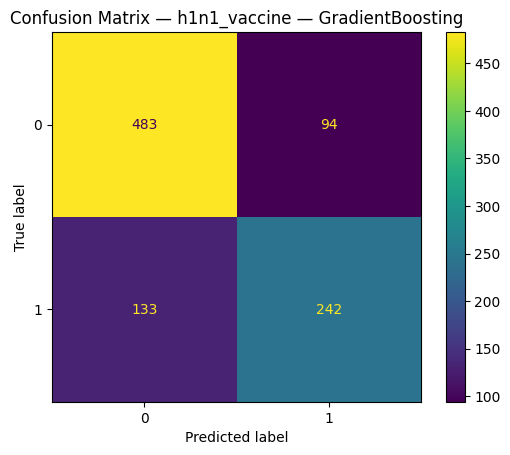

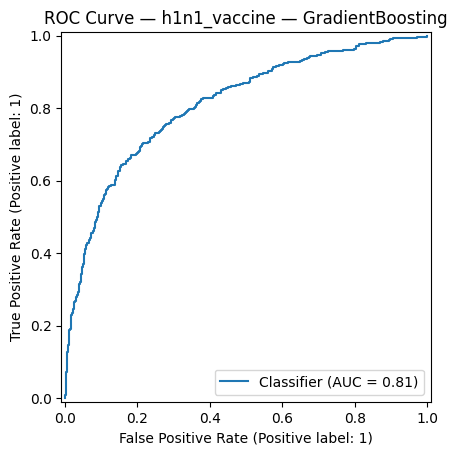


Top 30 features by importance — GradientBoosting (h1n1_vaccine)


,feature,importance
9,doctor_recc_h1n1,0.400309
14,opinion_h1n1_vacc_effective,0.172529
15,opinion_h1n1_risk,0.166475
12,health_worker,0.044022
16,opinion_h1n1_sick_from_vacc,0.019694
1,h1n1_knowledge,0.016212
63,employment_sector_technology,0.012774
17,household_adults,0.011724
23,age_group_65+ Years,0.010462
18,household_children,0.009360


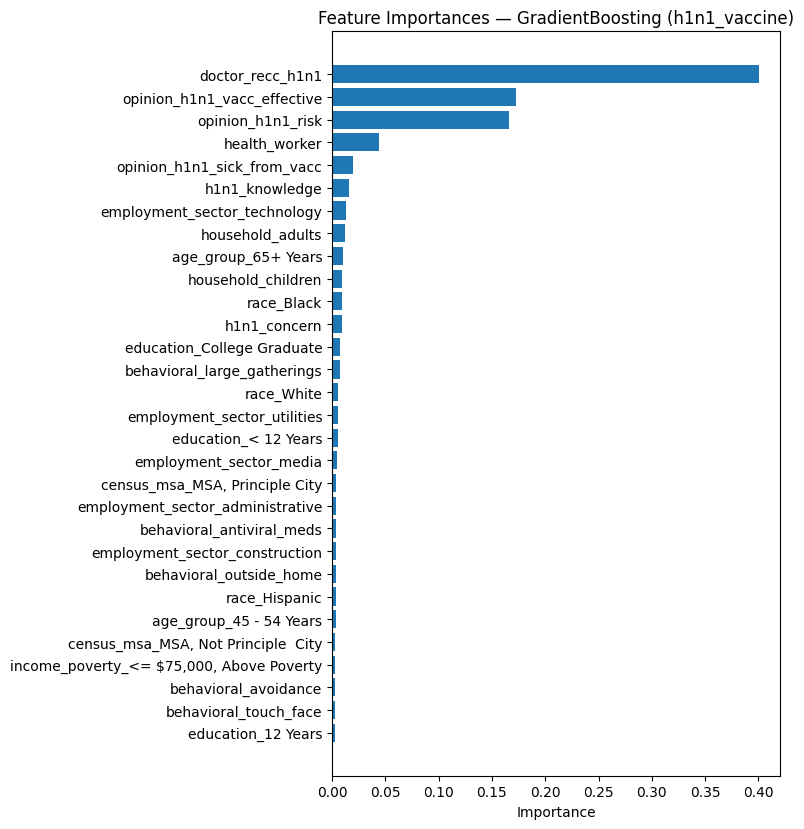


----------------------------------------------------------------------
Training: XGBoost

[XGBoost] Metrics — h1n1_vaccine
Accuracy  : 0.7458
Precision : 0.6905
Recall    : 0.6427
F1-score  : 0.6657
ROC-AUC   : 0.8007

Classification report:
              precision    recall  f1-score   support

           0     0.7778    0.8128    0.7949       577
           1     0.6905    0.6427    0.6657       375

    accuracy                         0.7458       952
   macro avg     0.7342    0.7277    0.7303       952
weighted avg     0.7434    0.7458    0.7440       952



<Figure size 640x480 with 0 Axes>

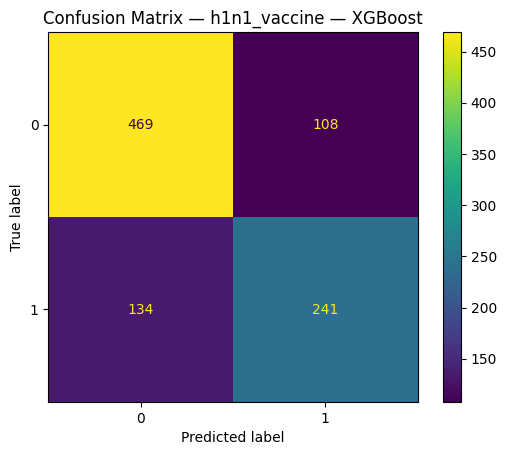

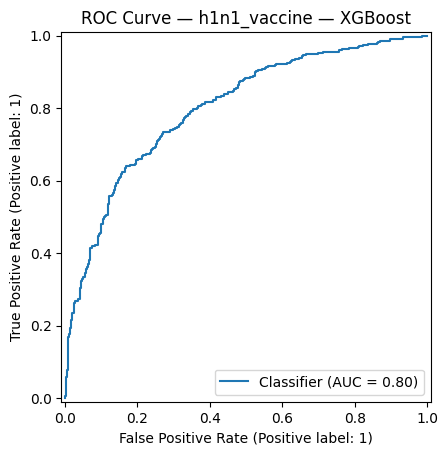


Top 30 features by importance — XGBoost (h1n1_vaccine)


,feature,importance
9,doctor_recc_h1n1,0.168417
12,health_worker,0.042620
15,opinion_h1n1_risk,0.039075
14,opinion_h1n1_vacc_effective,0.038847
63,employment_sector_technology,0.021124
57,employment_sector_media,0.016768
26,education_College Graduate,0.016678
28,race_Black,0.015768
1,h1n1_knowledge,0.014872
23,age_group_65+ Years,0.014676


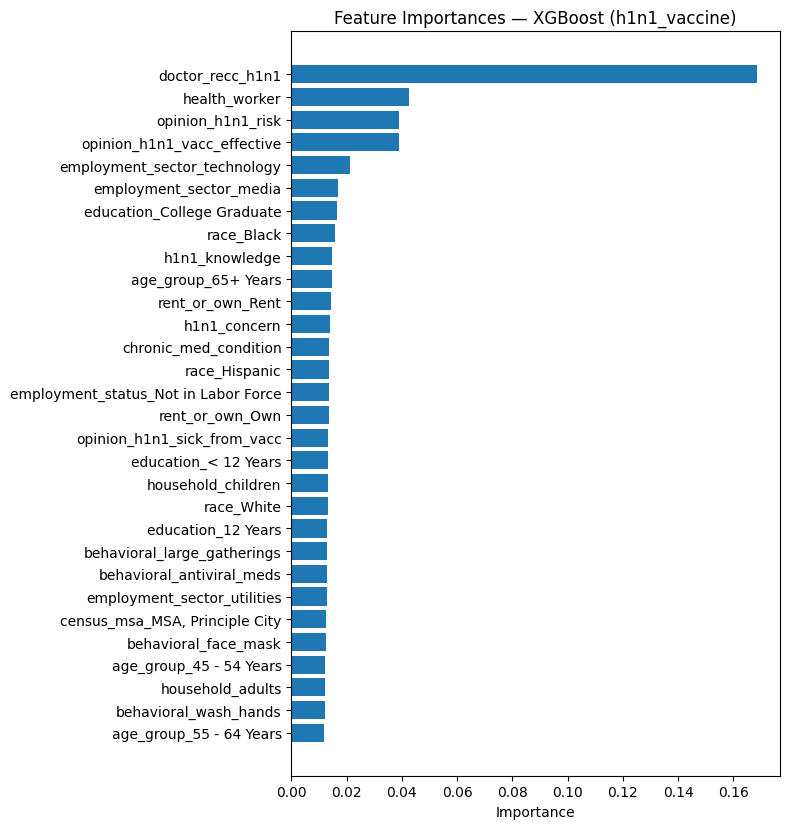


=== Combined Results Summary (sorted by ROC-AUC) ===


,target,accuracy,precision,recall,f1,roc_auc,model
2,h1n1_vaccine,0.741597,0.657702,0.717333,0.686224,0.815737,LogisticRegression
3,h1n1_vaccine,0.761555,0.720238,0.645333,0.680731,0.810704,GradientBoosting
1,h1n1_vaccine,0.741597,0.678670,0.653333,0.665761,0.801779,RandomForest_tuned
4,h1n1_vaccine,0.745798,0.690544,0.642667,0.665746,0.800721,XGBoost
0,h1n1_vaccine,0.745798,0.705882,0.608000,0.653295,0.795676,NaN


In [18]:
# =========================================================
# EXTRA MODELS: LogReg, GradientBoosting, Tuned RF (+ optional XGBoost)
# Appends to `results` and prints a combined summary.
# =========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import clone
# In case `results` wasn't defined for any reason
try:
    results
except NameError:
    results = []

def transformed_feature_names(preprocessor, num_cols, cat_cols):
    """Fit preprocessor (already fitted above in your RF block) and return output feature names."""
    out_num = num_cols
    out_cat = get_ohe_feature_names(preprocessor, cat_cols)
    return out_num + out_cat

def plot_and_report(y_val, y_pred, y_proba, target, model_name):
    """Common reporting: metrics, classification report, CM, ROC."""
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_val, y_proba)
    except ValueError:
        auc = np.nan

    print(f"\n[{model_name}] Metrics — {target}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    print("\nClassification report:")
    print(classification_report(y_val, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    plt.figure()
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {target} — {model_name}")
    plt.show()

    # ROC Curve
    try:
        RocCurveDisplay.from_predictions(y_val, y_proba)
        plt.title(f"ROC Curve — {target} — {model_name}")
        plt.show()
    except ValueError:
        pass

    return acc, prec, rec, f1, auc

def feature_ranking_from_model(pipe, X_train, model_name, top_k=30):
    """
    Show feature importance/weights if available (RF/GB: feature_importances_, LR: coef_).
    Uses the global `preprocessor`, `num_cols`, `cat_cols`.
    """
    # Build names from preprocessor fitted earlier
    preprocessor.fit(X_train)
    out_names = transformed_feature_names(preprocessor, num_cols, cat_cols)

    model = pipe.named_steps["clf"]
    fi_df = None

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        k = min(len(importances), len(out_names))
        fi_df = pd.DataFrame({"feature": out_names[:k], "importance": importances[:k]}) \
            .sort_values("importance", ascending=False).head(top_k)
        print(f"\nTop {top_k} features by importance — {model_name}")
        display(fi_df)
        plt.figure(figsize=(8, max(4, len(fi_df) * 0.28)))
        plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
        plt.title(f"Feature Importances — {model_name}")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

    elif hasattr(model, "coef_"):
        # For Logistic Regression: magnitude of coefficients
        coefs = np.ravel(model.coef_)
        k = min(len(coefs), len(out_names))
        fi_df = pd.DataFrame({"feature": out_names[:k], "weight": coefs[:k]})
        fi_df["abs_weight"] = fi_df["weight"].abs()
        fi_df = fi_df.sort_values("abs_weight", ascending=False).head(top_k)
        print(f"\nTop {top_k} features by |coefficient| — {model_name}")
        display(fi_df[["feature", "weight", "abs_weight"]])
        plt.figure(figsize=(8, max(4, len(fi_df) * 0.28)))
        plt.barh(fi_df["feature"][::-1], fi_df["abs_weight"][::-1])
        plt.title(f"Top |Coefficients| — {model_name}")
        plt.xlabel("|Coefficient|")
        plt.tight_layout()
        plt.show()
    else:
        print(f"(No feature importance/weights available for {model_name}.)")

# -----------------------------------------
# Define additional models
# -----------------------------------------
models_to_try = [
    ("RandomForest_tuned",
     RandomForestClassifier(
         n_estimators=800,
         max_depth=None,
         min_samples_split=2,
         min_samples_leaf=2,
         class_weight="balanced",
         n_jobs=-1,
         random_state=42
     )),
    ("LogisticRegression",
     LogisticRegression(
         max_iter=1500,
         class_weight="balanced",
         solver="lbfgs"
     )),
    ("GradientBoosting",
     GradientBoostingClassifier(
         random_state=42
     )),
]

# Try to add XGBoost if available
try:
    from xgboost import XGBClassifier
    models_to_try.append((
        "XGBoost",
        XGBClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=42,
            eval_metric="logloss"
        )
    ))
    print("✅ XGBoost detected — will train it too.")
except Exception as e:
    print("ℹ️ XGBoost not available — skipping. (Install with: pip install xgboost)")

# -----------------------------------------
# Train/evaluate each model per target
# -----------------------------------------
for target in available_targets:
    print("\n" + "="*78)
    print(f"MODEL ZOO for target: {target}")
    print("="*78)

    data = train_df.dropna(subset=[target]).copy()
    if data.empty:
        print(f"⚠️ Skipping {target}: no non-NaN labels found.")
        continue

    X = data[feature_cols]
    y = data[target].astype(int)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for model_name, model in models_to_try:
        print("\n" + "-"*70)
        print(f"Training: {model_name}")

        pipe = Pipeline(steps=[
            ("prep", preprocessor),
            ("clf", clone(model))
        ])
        pipe.fit(X_train, y_train)

        y_pred  = pipe.predict(X_val)
        # Not all models have predict_proba (but all we chose do). Guard anyway:
        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            y_proba = pipe.predict_proba(X_val)[:, 1]
        else:
            # Fallback via decision_function if present; else zeros
            if hasattr(pipe.named_steps["clf"], "decision_function"):
                scores = pipe.decision_function(X_val)
                # Min-max to [0,1] for plotting ROC
                y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
            else:
                y_proba = np.zeros_like(y_pred, dtype=float)

        acc, prec, rec, f1, auc = plot_and_report(y_val, y_pred, y_proba, target, model_name)

        # Feature ranking (if available)
        feature_ranking_from_model(pipe, X_train, f"{model_name} ({target})")

        # Save summary
        results.append({
            "model": model_name,
            "target": target,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "roc_auc": auc
        })

# -----------------------------------------
# Combined results table (including earlier RF baseline)
# -----------------------------------------
res_df = pd.DataFrame(results)
if not res_df.empty:
    print("\n=== Combined Results Summary (sorted by ROC-AUC) ===")
    display(res_df.sort_values(["target", "roc_auc"], ascending=[True, False]))
else:
    print("No results to show — check earlier steps.")
